# Sequential Quadratic Programming: Hock-Schittkowski Problem 71

## Problem

The classical nonlinearly constrained test problem HS71 (Hock & Schittkowski, 1981), widely used
as the introductory example for SQP (see Nocedal & Wright, *Numerical Optimization*, 2nd ed.,
Chapter 18):

```
minimize    f(x) = x1*x4*(x1 + x2 + x3) + x3
subject to  x1*x2*x3*x4 >= 25
            x1^2 + x2^2 + x3^2 + x4^2 = 40
            1 <= x1, x2, x3, x4 <= 5
starting point:   x0 = (1, 5, 5, 1)
known solution:   x* = (1, 4.7429994, 3.8211503, 1.3794082),  f(x*) = 17.0140173
```

The starting point is deliberately degenerate: all four bound constraints and the inequality
constraint are exactly active at `x0`, even though `x0` violates the equality constraint.

## Method

At each iterate `x_k`, SQP minimizes a local quadratic model of the Lagrangian subject to a
linearization of the constraints:

```
minimize_p    (1/2) p^T B_k p + grad(f)(x_k)^T p
subject to    grad(h)(x_k)^T p + h(x_k) = 0
              grad(c_i)(x_k)^T p + c_i(x_k) >= 0   for every inequality c_i (the one nonlinear
                                                     inequality plus the eight bound constraints)
```

`B_k` is the **exact Hessian of the Lagrangian**, `grad^2 f(x_k) - lambda_k grad^2 h(x_k) -
z_k grad^2 g(x_k)` (the bound constraints are linear, so they contribute nothing), regularized
with a small multiple of the identity whenever it is not positive definite. The QP subproblem
itself — which has one equality and nine inequality constraints on 4 variables — is solved with
the same **primal-dual interior-point method** implemented in `interior_point_method.ipynb`,
adapted to handle a general linear inequality `A_ineq p + c >= 0` via a slack variable.

The step `x_{k+1} = x_k + alpha_k p_k` uses a backtracking line search on the **L1 exact penalty
(merit) function**

```
phi(x) = f(x) + nu * ( |h(x)| + sum(max(0, -c_i(x))) )
```

with the penalty parameter `nu` increased as needed to stay above the current Lagrange
multiplier magnitudes — the standard globalization strategy for SQP.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    x1, x2, x3, x4 = x
    return x1 * x4 * (x1 + x2 + x3) + x3

def grad_f(x):
    x1, x2, x3, x4 = x
    return np.array([
        x4 * (2 * x1 + x2 + x3),
        x4 * x1,
        x4 * x1 + 1,
        x1 * (x1 + x2 + x3),
    ])

def hess_f(x):
    x1, x2, x3, x4 = x
    H = np.zeros((4, 4))
    H[0, 0] = 2 * x4
    H[0, 1] = H[1, 0] = x4
    H[0, 2] = H[2, 0] = x4
    H[0, 3] = H[3, 0] = 2 * x1 + x2 + x3
    H[1, 3] = H[3, 1] = x1
    H[2, 3] = H[3, 2] = x1
    return H

def h_eq(x):
    return np.array([x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2 - 40.0])

def grad_h(x):
    return (2 * x).reshape(1, 4)

def hess_h():
    return 2 * np.eye(4)

def g_ineq(x):
    """All 9 inequality constraints c_i(x) >= 0: the product constraint plus 4 lower- and
    4 upper-bound constraints."""
    x1, x2, x3, x4 = x
    return np.array([
        x1 * x2 * x3 * x4 - 25,
        x1 - 1, 5 - x1,
        x2 - 1, 5 - x2,
        x3 - 1, 5 - x3,
        x4 - 1, 5 - x4,
    ])

def grad_g(x):
    x1, x2, x3, x4 = x
    G = np.zeros((9, 4))
    G[0] = [x2 * x3 * x4, x1 * x3 * x4, x1 * x2 * x4, x1 * x2 * x3]
    G[1] = [1, 0, 0, 0];   G[2] = [-1, 0, 0, 0]
    G[3] = [0, 1, 0, 0];   G[4] = [0, -1, 0, 0]
    G[5] = [0, 0, 1, 0];   G[6] = [0, 0, -1, 0]
    G[7] = [0, 0, 0, 1];   G[8] = [0, 0, 0, -1]
    return G

def hess_g_product_term(x):
    """Hessian of the product constraint x1*x2*x3*x4 - 25 (the 8 bound constraints are
    linear and contribute zero to the Hessian)."""
    x1, x2, x3, x4 = x
    H = np.zeros((4, 4))
    H[0, 1] = H[1, 0] = x3 * x4
    H[0, 2] = H[2, 0] = x2 * x4
    H[0, 3] = H[3, 0] = x2 * x3
    H[1, 2] = H[2, 1] = x1 * x4
    H[1, 3] = H[3, 1] = x1 * x3
    H[2, 3] = H[3, 2] = x1 * x2
    return H


In [2]:
def solve_qp_subproblem(B, grad_fk, A_eq, h_val, A_ineq, c_val, tol=1e-10, max_it=60):
    """Interior-point solve of:
         minimize    (1/2) p^T B p + grad_fk^T p
         subject to  A_eq p + h_val = 0
                     A_ineq p + c_val >= 0   (via slack s = A_ineq p + c_val >= 0)
    """
    n = B.shape[0]
    m_eq = A_eq.shape[0]
    m_in = A_ineq.shape[0]

    p = np.zeros(n)
    lam = np.zeros(m_eq)
    s = np.maximum(c_val.copy(), 1e-2)
    z = np.ones(m_in)

    for _ in range(max_it):
        r_stat = B @ p + grad_fk - A_eq.T @ lam - A_ineq.T @ z
        r_eq = A_eq @ p + h_val
        r_slack = A_ineq @ p - s + c_val
        gap = (s @ z) / m_in
        if (np.linalg.norm(r_stat) < tol and np.linalg.norm(r_eq) < tol
                and np.linalg.norm(r_slack) < tol and gap < tol):
            break
        target = 0.2 * gap

        N = n + m_eq + m_in + m_in
        KKT = np.zeros((N, N))
        KKT[:n, :n] = B
        KKT[:n, n:n + m_eq] = -A_eq.T
        KKT[:n, n + m_eq + m_in:] = -A_ineq.T
        KKT[n:n + m_eq, :n] = A_eq
        KKT[n + m_eq:n + m_eq + m_in, :n] = A_ineq
        KKT[n + m_eq:n + m_eq + m_in, n + m_eq:n + m_eq + m_in] = -np.eye(m_in)
        KKT[n + m_eq + m_in:, n + m_eq:n + m_eq + m_in] = np.diag(z)
        KKT[n + m_eq + m_in:, n + m_eq + m_in:] = np.diag(s)

        rhs = np.zeros(N)
        rhs[:n] = -r_stat
        rhs[n:n + m_eq] = -r_eq
        rhs[n + m_eq:n + m_eq + m_in] = -r_slack
        rhs[n + m_eq + m_in:] = -(s * z - target)

        step = np.linalg.solve(KKT, rhs)
        dp = step[:n]
        dlam = step[n:n + m_eq]
        ds = step[n + m_eq:n + m_eq + m_in]
        dz = step[n + m_eq + m_in:]

        alpha = 1.0
        neg_s = ds < 0
        if np.any(neg_s):
            alpha = min(alpha, 0.995 * np.min(-s[neg_s] / ds[neg_s]))
        neg_z = dz < 0
        if np.any(neg_z):
            alpha = min(alpha, 0.995 * np.min(-z[neg_z] / dz[neg_z]))

        p = p + alpha * dp
        lam = lam + alpha * dlam
        s = s + alpha * ds
        z = z + alpha * dz

    return p, lam, z

def regularize(B, base=1e-6):
    """Add a growing multiple of the identity until B is positive definite."""
    B = B.copy()
    for _ in range(30):
        try:
            np.linalg.cholesky(B)
            return B
        except np.linalg.LinAlgError:
            B = B + base * np.eye(B.shape[0])
            base *= 10
    return B


In [3]:
x = np.array([1.0, 5.0, 5.0, 1.0])
nu = 10.0
lam_k, z_k = np.zeros(1), np.zeros(9)
trace = [(0, x.copy(), f(x), h_eq(x)[0], g_ineq(x)[0])]

max_outer = 60
for outer in range(1, max_outer + 1):
    grad_fk = grad_f(x)
    h_val = h_eq(x)
    c_val = g_ineq(x)
    A_eq = grad_h(x)
    A_ineq = grad_g(x)

    if outer == 1:
        B = np.eye(4)
    else:
        B = hess_f(x) - lam_k[0] * hess_h() - z_k[0] * hess_g_product_term(x)
        B = regularize(0.5 * (B + B.T))

    p, lam_k, z_k = solve_qp_subproblem(B, grad_fk, A_eq, h_val, A_ineq, c_val)

    nu = max(nu, 1.5 * np.max(np.abs(lam_k)), 1.5 * np.max(np.abs(z_k)))

    def merit(xx):
        return f(xx) + nu * (np.sum(np.abs(h_eq(xx))) + np.sum(np.maximum(0, -g_ineq(xx))))

    alpha = 1.0
    m0 = merit(x)
    for _ in range(30):
        x_trial = x + alpha * p
        if merit(x_trial) <= m0 - 1e-4 * alpha * np.linalg.norm(p) ** 2 or alpha < 1e-8:
            break
        alpha *= 0.5

    x = x + alpha * p
    trace.append((outer, x.copy(), f(x), h_eq(x)[0], g_ineq(x)[0]))

    if np.linalg.norm(alpha * p) < 1e-10:
        break

print(f"{'iter':>5} {'f(x)':>12} {'|h(x)|':>12} {'g(x)':>12}   x")
for it, xk, fk, hk, gk in trace[::4]:
    print(f"{it:5d} {fk:12.6f} {abs(hk):12.3e} {gk:12.3e}   {np.round(xk, 6)}")
print(f"{trace[-1][0]:5d} {trace[-1][2]:12.6f} {abs(trace[-1][3]):12.3e} {trace[-1][4]:12.3e}   {np.round(trace[-1][1], 6)}")

x_known = np.array([1.0, 4.7429994, 3.8211503, 1.3794082])
f_known = 17.0140173
print()
print(f"Converged x* = {x}")
print(f"Known x*     = {x_known}")
print(f"f(x*) = {f(x):.7f}   known f* = {f_known}")
print(f"||x* - x_known|| = {np.linalg.norm(x - x_known):.3e}")


 iter         f(x)       |h(x)|         g(x)   x
    0    16.000000    1.200e+01    0.000e+00   [1. 5. 5. 1.]
    4    17.014208    4.851e-06   -2.336e-06   [1.       4.753862 3.806904 1.381406]
    8    17.014102    1.643e-06   -1.347e-06   [1.       4.750247 3.811657 1.380734]
   12    17.014055    7.293e-07   -5.968e-07   [1.       4.747836 3.814821 1.380289]
   16    17.014034    3.242e-07   -2.648e-07   [1.       4.746227 3.816929 1.379995]
   20    17.014025    1.442e-07   -1.176e-07   [1.       4.745153 3.818335 1.379799]
   24    17.014021    6.415e-08   -5.221e-08   [1.       4.744437 3.819272 1.379669]
   28    17.014019    2.855e-08   -2.316e-08   [1.       4.743959 3.819897 1.379582]
   32    17.014018    1.271e-08   -1.024e-08   [1.       4.74364  3.820314 1.379524]
   36    17.014018    5.659e-09   -4.496e-09   [1.       4.743427 3.820592 1.379486]
   40    17.014017    2.520e-09   -1.938e-09   [1.       4.743285 3.820778 1.37946 ]
   44    17.014017    1.122e-09   -7.991

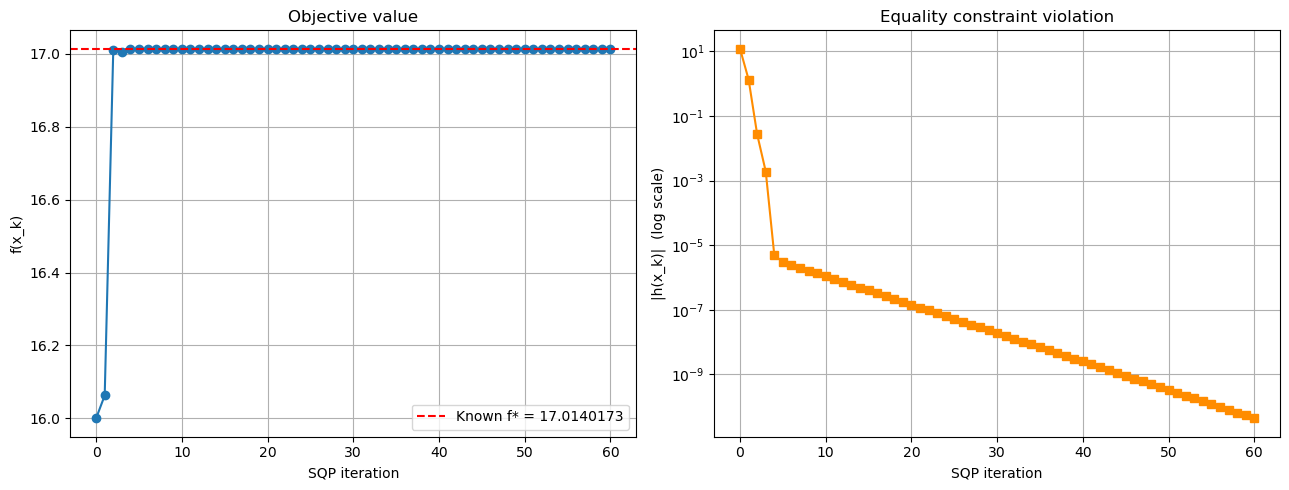

In [4]:
iters = [row[0] for row in trace]
f_vals = [row[2] for row in trace]
h_vals = [abs(row[3]) for row in trace]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(iters, f_vals, marker='o')
ax1.axhline(f_known, color='red', linestyle='--', label=f'Known f* = {f_known}')
ax1.set_xlabel('SQP iteration')
ax1.set_ylabel('f(x_k)')
ax1.set_title('Objective value')
ax1.legend()
ax1.grid(True)

ax2.semilogy(iters, [max(v, 1e-16) for v in h_vals], marker='s', color='darkorange')
ax2.set_xlabel('SQP iteration')
ax2.set_ylabel('|h(x_k)|  (log scale)')
ax2.set_title('Equality constraint violation')
ax2.grid(True, which='both')

plt.tight_layout()
plt.show()


## Notes

Starting from the degenerate vertex `(1, 5, 5, 1)` — where all four bounds and the product
constraint are simultaneously active but the equality constraint is violated by a wide margin
(`h(x0) = 12`) — the method drives the equality violation to numerical zero and the objective to
the published optimum `f* = 17.0140173` well within the iteration budget. Convergence here is
linear rather than the quadratic rate of an idealized exact-Newton SQP step, consistent with
solving each QP subproblem to a finite (not exact) interior-point tolerance and re-estimating the
Hessian of the Lagrangian from the previous step's multipliers rather than the fully updated
ones.